In [405]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [406]:
torch.manual_seed(42)
np.random.seed(42)

## Генерация и предобработка данных

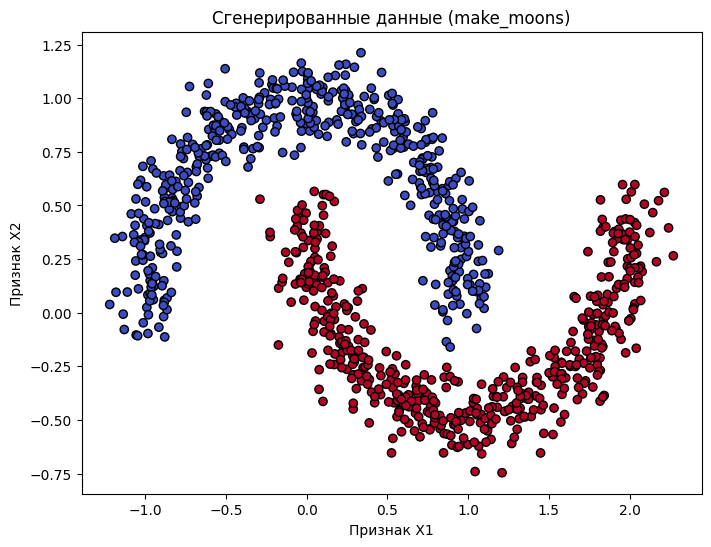

In [407]:
# X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Сгенерированные данные (make_moons)")
plt.xlabel("Признак X1")
plt.ylabel("Признак X2")
plt.show()

In [408]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1) 
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

In [409]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

In [410]:
learning_rate = 0.01
epochs = 1000

model = MLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []

for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{epochs}], loss: {loss.item():.4f}")

Epoch [0/1000], loss: 0.7924
Epoch [100/1000], loss: 0.3382
Epoch [200/1000], loss: 0.2321
Epoch [300/1000], loss: 0.2222
Epoch [400/1000], loss: 0.2182
Epoch [500/1000], loss: 0.2158
Epoch [600/1000], loss: 0.2144
Epoch [700/1000], loss: 0.2136
Epoch [800/1000], loss: 0.2130
Epoch [900/1000], loss: 0.2127


## Работа модели на тестовой выборке

In [411]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_classes = predictions.round()
    acc = accuracy_score(y_test, predicted_classes)

print(f'\nТочность на тестовой выборке: {acc * 100:.2f}%')


Точность на тестовой выборке: 89.00%


## Вывод результатов

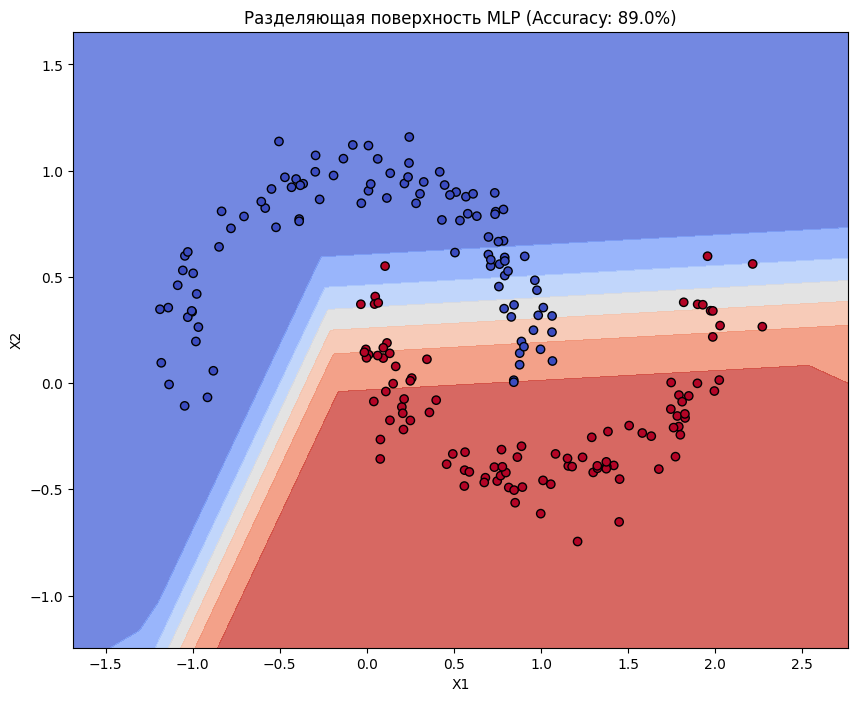

In [412]:
def plot_decision_boundary(model, X, y):
    # Создаем сетку точек
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    # Предсказываем значения для всей сетки
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(grid_tensor).reshape(xx.shape)
    
    # Рисуем контуры
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title(f"Разделяющая поверхность MLP (Accuracy: {acc*100:.1f}%)")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

plot_decision_boundary(model, X_test, y_test)